# 04 — Anomaly Detection & Early Warning

Residuals of the naive seasonal baseline (y(t) - y(t-52)) -> z-score + Isolation Forest. COVID-era weeks use a pre-2022 baseline (spec L3). Output: `reports/anomaly_log.csv`.

In [1]:
import sys; sys.path.insert(0, '.')
import pandas as pd
import matplotlib.pyplot as plt
from src.anomaly import detect, episode_log, covid_backtest
w = pd.read_parquet('data/processed/weekly_top10.parquet')
print('Method: residual = actual - value same ISO week last year. Past actuals are known at forecast time, so this is leakage-free in-sample scoring.')

Method: residual = actual - value same ISO week last year. Past actuals are known at forecast time, so this is leakage-free in-sample scoring.


## COVID backtest (2020–2021, pre-2022 baseline)

Strongest episodes line up with documented events: the May-2020 export spike (unusually high activity vs 2019 baseline as China recovered first), the Delta wave (May 2021), and the September-2021 PPKM Level 4 drop.

In [2]:
pri = w[w.portname=='Tanjung Priok'].set_index('year_week')['portcalls_container']
cov = covid_backtest(pri)
cov_events = cov[cov.anomaly | cov.iforest_anom]
print(cov_events[['y','baseline','resid','z']].round(1).to_string())

              y  baseline  resid    z
year_week                            
202022     58.0      19.0   39.0  3.9
202119     51.0      80.0  -29.0 -3.1
202137     55.0      82.0  -27.0 -2.8
202236     83.0      55.0   28.0  2.8
202242     92.0      64.0   28.0  2.8
202415     40.0      67.0  -27.0 -2.8
202623     80.0     105.0  -25.0 -2.6


## 2022+ early-warning log (all top-10 ports)

In [3]:
log = pd.read_csv('reports/anomaly_log.csv')
strong = log.sort_values('max_abs_z', ascending=False).head(12)
print(strong.to_string(index=False))

      portname              target  start_yw  end_yw   dir  max_abs_z  n_weeks
 Tanjung Priok portcalls_container    202022  202022 spike   3.911316        1
      Surabaya portcalls_container    202022  202022 spike   3.532671        1
Manokwari Road portcalls_container    202339  202339 spike   3.441614        1
       Kendari portcalls_container    202617  202617  drop   3.243328        1
   Teluk Bayur portcalls_container    202414  202414  drop   3.225791        1
 Tanjung Priok portcalls_container    202415  202415  drop   3.069375        1
 Tanjung Priok portcalls_container    202119  202119  drop   3.051446        1
        Bitung portcalls_container    202411  202411  drop   2.989208        1
       Kendari portcalls_container    202533  202533 spike   2.935334        1
      Makassar portcalls_container    202326  202326  drop   2.920040        1
   Teluk Bayur portcalls_container    202415  202415 spike   2.858709        1
 Tanjung Priok portcalls_container    202623  202623

## Event interpretation

- **2024-W15 drop, multi-port (Priok, Teluk Bayur):** Lebaran week (10 Apr 2024) — the recurring national holiday shutdown.
- **2023 drops (Teluk Bayur, Makassar):** mid-2023 low-activity period consistent with the global freight recession.
- **2021-05 / 2021-09 (Priok, Surabaya):** Delta wave & PPKM restrictions.
- **2020-W22 spike:** activity rebound vs 2019 baseline as trade restarted after the first lockdown.

The layer catches real, datable events — that is the early-warning story.

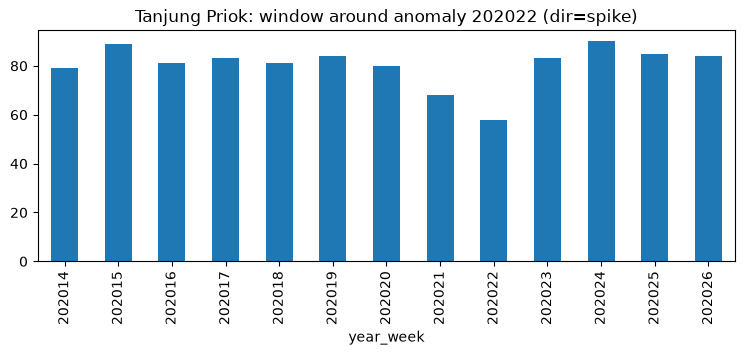

In [4]:
top = strong.head(1)
row = top.iloc[0]
s = w[w.portname==row.portname].set_index('year_week')['portcalls_container']
seg = s[(s.index >= row.start_yw - 8) & (s.index <= row.start_yw + 4)]
seg.plot(kind='bar', figsize=(9,3), title=f'{row.portname}: window around anomaly {row.start_yw} (dir={row.dir})')
plt.savefig('reports/figures/04_anomaly_window.png', dpi=120); plt.show()